# 🐟 Fish Classification: From Human Rules to Machine Learning

This notebook introduces the core idea behind **Machine Learning (ML)**:
instead of a human manually writing rules to solve a problem, we let an algorithm *find* the best rule automatically.

We'll use a simple but concrete example — classifying fish into two species:

- 🔵 **Atlantic Salmon**
- 🟠 **Brown Trout**

…based on two physical measurements taken in the field.

---

## The Problem

A marine biologist wants to identify the species of a fish from two measurements:

| Feature | Description |
|---|---|
| **Body length** | Total length of the fish, tip to tail (cm) |
| **Dorsal fin length** | Length of the main fin on the fish's back (cm) |

Both species are similar-looking and their measurements **overlap** — there is no clean, perfect split.
This makes it a realistic and interesting classification challenge.

> 💡 **Goal:** Given a fish's body length and fin length, predict whether it is a *Salmon* or a *Brown Trout*.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import pandas as pd

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12})

# Fixed seed — run this notebook multiple times and you'll always get the same fish!
np.random.seed(42)

---
## 1. The Dataset

We'll generate **synthetic** (made-up, but realistic) measurements for 300 fish — 150 per species.
Each fish's body length and fin length are drawn from a Normal distribution:

| Species | Body Length | Dorsal Fin Length |
|---|---|---|
| **Salmon** | Mean **60 cm**, Std 8 cm | Mean **18 cm**, Std 4 cm |
| **Brown Trout** | Mean **42 cm**, Std 8 cm | Mean **12 cm**, Std 4 cm |

Notice that the ranges **overlap** — a large trout (say, 55 cm) can be longer than a small salmon (say, 47 cm).
This overlap makes the classification problem non-trivial and is where ML shines.

In [2]:
N = 150   # fish per species

# --- Salmon ---
salmon_length = np.random.normal(loc=60, scale=8, size=N)
salmon_fin    = np.random.normal(loc=18, scale=4, size=N)

# --- Brown Trout ---
trout_length  = np.random.normal(loc=42, scale=8, size=N)
trout_fin     = np.random.normal(loc=12, scale=4, size=N)

# Combine into a single DataFrame
df = pd.DataFrame({
    'body_length': np.concatenate([salmon_length, trout_length]),
    'fin_length':  np.concatenate([salmon_fin,    trout_fin]),
    'species':     ['Salmon'] * N + ['Brown Trout'] * N
})

print(f"Total fish in dataset: {len(df)}\n")
print("Summary statistics per species:")
df.groupby('species')[['body_length', 'fin_length']].describe().round(1)

Total fish in dataset: 300

Summary statistics per species:


body_length                                          fin_length  \
                  count  mean  std   min   25%   50%   75%   max      count   
species                                                                       
Brown Trout       150.0  42.4  7.6  25.0  37.2  42.3  47.5  59.5      150.0   
Salmon            150.0  59.3  7.5  39.0  54.6  59.6  63.9  79.7      150.0   

                                                     
             mean  std  min   25%   50%   75%   max  
species                                              
Brown Trout  11.6  3.9  2.1   9.0  11.4  14.1  24.3  
Salmon       18.3  4.1  5.0  15.2  18.6  20.7  33.4

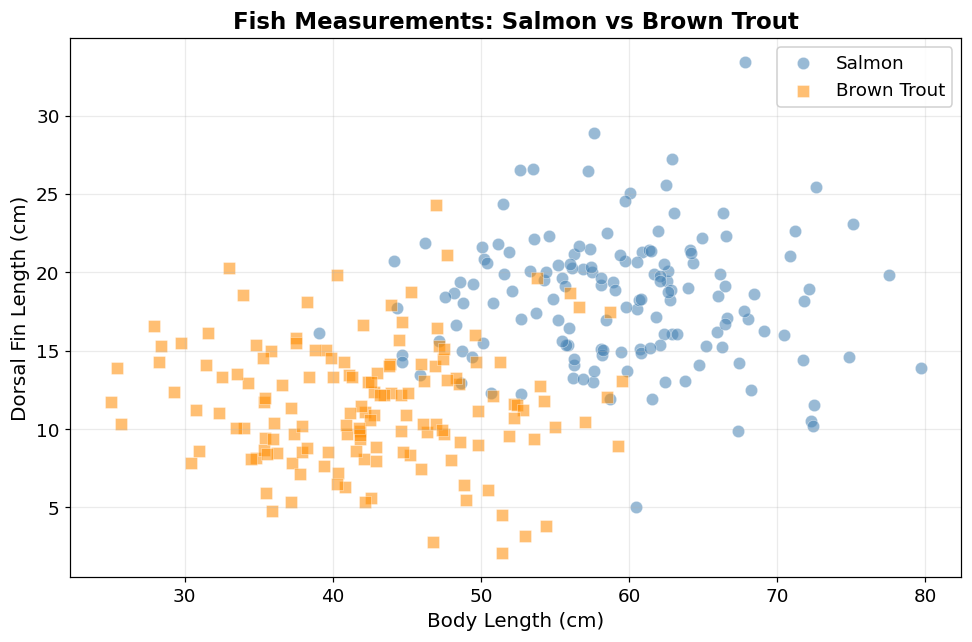


Overlap in body length:
  Salmon range:      39.0 – 79.7 cm
  Brown Trout range: 25.0 – 59.5 cm
  Overlap zone:      39.0 – 59.5 cm  ← ambiguous fish live here!


In [3]:
# ── Scatter plot of the raw data ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

SALMON_COLOUR = 'steelblue'
TROUT_COLOUR  = 'darkorange'

for species, colour, marker in [
    ('Salmon',      SALMON_COLOUR, 'o'),
    ('Brown Trout', TROUT_COLOUR,  's')
]:
    mask = df['species'] == species
    ax.scatter(
        df.loc[mask, 'body_length'], df.loc[mask, 'fin_length'],
        alpha=0.55, color=colour, marker=marker, s=65,
        edgecolors='white', linewidth=0.4, label=species
    )

ax.set_xlabel('Body Length (cm)', fontsize=13)
ax.set_ylabel('Dorsal Fin Length (cm)', fontsize=13)
ax.set_title('Fish Measurements: Salmon vs Brown Trout', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Summarise the overlap
print("\nOverlap in body length:")
print(f"  Salmon range:      {salmon_length.min():.1f} – {salmon_length.max():.1f} cm")
print(f"  Brown Trout range: {trout_length.min():.1f} – {trout_length.max():.1f} cm")
overlap_lo = max(salmon_length.min(), trout_length.min())
overlap_hi = min(salmon_length.max(), trout_length.max())
print(f"  Overlap zone:      {overlap_lo:.1f} – {overlap_hi:.1f} cm  ← ambiguous fish live here!")

---
## 2. Approach 1 — Human-Written Rules

A fish biologist studies the data and writes some rules based on domain knowledge:

> *"Salmon are generally bigger than Trout.
> If a fish is longer than **51 cm** (halfway between the two average lengths),
> it's probably a Salmon."*

In code, this becomes a simple `if / else` statement:

```
if body_length > 51:
    → Salmon
else:
    → Brown Trout
```

This is intuitive and easy to explain. Let's see how accurate it is.

In [4]:
# ── Human rule classifier ─────────────────────────────────────────────────────
HUMAN_THRESHOLD = 51   # cm — the midpoint between the two species' average lengths

def human_classify(body_length, fin_length):
    """Simple rule written by a domain expert — only uses body length."""
    if body_length > HUMAN_THRESHOLD:
        return 'Salmon'
    else:
        return 'Brown Trout'

# Apply the rule to every fish in the dataset
df['human_pred'] = df.apply(
    lambda row: human_classify(row['body_length'], row['fin_length']),
    axis=1
)

# ── Evaluate accuracy ─────────────────────────────────────────────────────────
human_correct  = (df['human_pred'] == df['species']).sum()
human_accuracy = human_correct / len(df) * 100

print(f"Human rule: 'if body_length > {HUMAN_THRESHOLD} cm → Salmon'")
print(f"-" * 48)
print(f"Correct:  {human_correct} / {len(df)} fish")
print(f"Accuracy: {human_accuracy:.1f}%\n")

for species in ['Salmon', 'Brown Trout']:
    mask = df['species'] == species
    sp_acc = (df.loc[mask, 'human_pred'] == species).mean() * 100
    n_wrong = (df.loc[mask, 'human_pred'] != species).sum()
    print(f"  {species:<15} {sp_acc:.1f}% correct  ({n_wrong} misclassified)")

Human rule: 'if body_length > 51 cm → Salmon'
------------------------------------------------
Correct:  255 / 300 fish
Accuracy: 85.0%

  Salmon          84.7% correct  (23 misclassified)
  Brown Trout     85.3% correct  (22 misclassified)


### Why does this fall short?

The rule looks at **body length only** and completely **ignores fin length**.

- A **short Salmon** (e.g. 46 cm) with a **large fin** (e.g. 22 cm) gets *misclassified as Trout*.
- A **long Trout** (e.g. 57 cm) with a **small fin** (e.g. 9 cm) gets *misclassified as Salmon*.

You *could* try adding extra rules — but it quickly becomes fragile:
- What's the right fin threshold to add?
- Should you use `AND` or `OR`?
- Does adding the second rule actually help, or does it hurt one species while helping the other?

Manually tuning a cascade of rules is hard work, and it gets much harder as the number of features grows.

**This is exactly the problem Machine Learning is designed to solve.**

---
## 3. Approach 2 — Machine Learning: A Learned Equation

Instead of writing separate rules for each feature, an ML algorithm finds a **single equation**
that combines *all* features at once into a **score**:

$$\text{score} = w_1 \times \text{body\_length} + w_2 \times \text{fin\_length} + b$$

The decision rule is then simply:

| Score | Prediction |
|---|---|
| **score > 0** | Salmon |
| **score ≤ 0** | Brown Trout |

The algorithm's job is to find the best values of:
- **w₁** — how much body length should count
- **w₂** — how much fin length should count
- **b** — a bias / intercept term that shifts the boundary up or down

This type of classifier is called **Logistic Regression** — one of the simplest and most
widely-used ML algorithms. Its decision boundary is a **straight line** (in 2D), or a
**hyperplane** when there are more features.

> 🔍 **Note:** In a real ML pipeline you would *train* the model on labelled data to find
> these weights automatically. Here, we'll use weights that have already been found so you can
> see that the approach actually *works*.

In [5]:
# ── ML weights (as if discovered by a training algorithm) ─────────────────────
#
#   These values were found by asking: "what line best separates the two
#   clusters in the length-vs-fin space?"
#   A trained Logistic Regression would arrive at very similar numbers.
#
W_LENGTH = 0.5     # weight for body length
W_FIN    = 1.0     # weight for fin length  (fin matters more per cm of difference!)
BIAS     = -42.0   # intercept

print(f"ML equation:")
print(f"  score = {W_LENGTH} × body_length  +  {W_FIN} × fin_length  +  ({BIAS})")
print(f"  if score > 0  →  Salmon")
print(f"  if score ≤ 0  →  Brown Trout")
print()

# ── Let's verify by hand on a couple of example fish ─────────────────────────
examples = [
    ('Obvious Salmon',     70, 22),
    ('Obvious Trout',      35,  9),
    ('Borderline fish 1',  53, 14),
    ('Borderline fish 2',  48, 18),
]

print(f"{'Fish':<22} {'Length':>8} {'Fin':>6}  {'Score':>8}  {'Prediction':<15}")
print("-" * 68)
for name, length, fin in examples:
    score = W_LENGTH * length + W_FIN * fin + BIAS
    pred  = 'Salmon' if score > 0 else 'Brown Trout'
    print(f"{name:<22} {length:>7} cm  {fin:>4} cm  {score:>+8.1f}  {pred}")

ML equation:
  score = 0.5 × body_length  +  1.0 × fin_length  +  (-42.0)
  if score > 0  →  Salmon
  if score ≤ 0  →  Brown Trout

Fish                     Length    Fin     Score  Prediction     
--------------------------------------------------------------------
Obvious Salmon              70 cm    22 cm     +15.0  Salmon
Obvious Trout               35 cm     9 cm     -15.5  Brown Trout
Borderline fish 1           53 cm    14 cm      -1.5  Brown Trout
Borderline fish 2           48 cm    18 cm      +0.0  Brown Trout


Notice how the **borderline fish** are handled:

- Fish 1 (53 cm body, 14 cm fin): moderately long but small fin — the two signals pull in opposite directions.
  The equation *weighs them up* and makes a single call.
- Fish 2 (48 cm body, 18 cm fin): short body but large fin — the fin length tips the balance toward Salmon.
  The human rule (which ignores fin) would call this a **Trout** — which might well be wrong!

This is the key advantage: the equation **simultaneously considers all features**, letting them
compensate for each other.

In [6]:
# ── Apply the ML classifier to the full dataset ───────────────────────────────
def ml_score(body_length, fin_length):
    return W_LENGTH * body_length + W_FIN * fin_length + BIAS

def ml_classify(body_length, fin_length):
    return 'Salmon' if ml_score(body_length, fin_length) > 0 else 'Brown Trout'

df['ml_score'] = df.apply(lambda r: ml_score(r['body_length'], r['fin_length']), axis=1)
df['ml_pred']  = df.apply(lambda r: ml_classify(r['body_length'], r['fin_length']), axis=1)

# ── Evaluate accuracy ─────────────────────────────────────────────────────────
ml_correct  = (df['ml_pred'] == df['species']).sum()
ml_accuracy = ml_correct / len(df) * 100

print(f"ML classifier accuracy")
print(f"-" * 48)
print(f"Correct:  {ml_correct} / {len(df)} fish")
print(f"Accuracy: {ml_accuracy:.1f}%\n")

for species in ['Salmon', 'Brown Trout']:
    mask = df['species'] == species
    sp_acc = (df.loc[mask, 'ml_pred'] == species).mean() * 100
    n_wrong = (df.loc[mask, 'ml_pred'] != species).sum()
    print(f"  {species:<15} {sp_acc:.1f}% correct  ({n_wrong} misclassified)")

ML classifier accuracy
------------------------------------------------
Correct:  275 / 300 fish
Accuracy: 91.7%

  Salmon          88.0% correct  (18 misclassified)
  Brown Trout     95.3% correct  (7 misclassified)


---
## 4. Visualising the Decision Boundaries

The most illuminating way to compare the two approaches is to plot the **decision boundary** —
the line that separates "predict Salmon" from "predict Brown Trout".

**Human rule:** a vertical line at body_length = 51 cm. It can only ask *"is the fish long enough?"*

**ML equation:** a diagonal line defined by `score = 0`:

$$0 = 0.5 \times \text{body\_length} + 1.0 \times \text{fin\_length} - 42$$
$$\Rightarrow \text{fin\_length} = 42 - 0.5 \times \text{body\_length}$$

This line asks *"is the right **combination** of length and fin present?"*
Red outlines ⭕ mark misclassified fish.

/tmp/ipykernel_83635/3896051488.py:72: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/finley/Work/RDS/CfRR/intro_to_llms/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


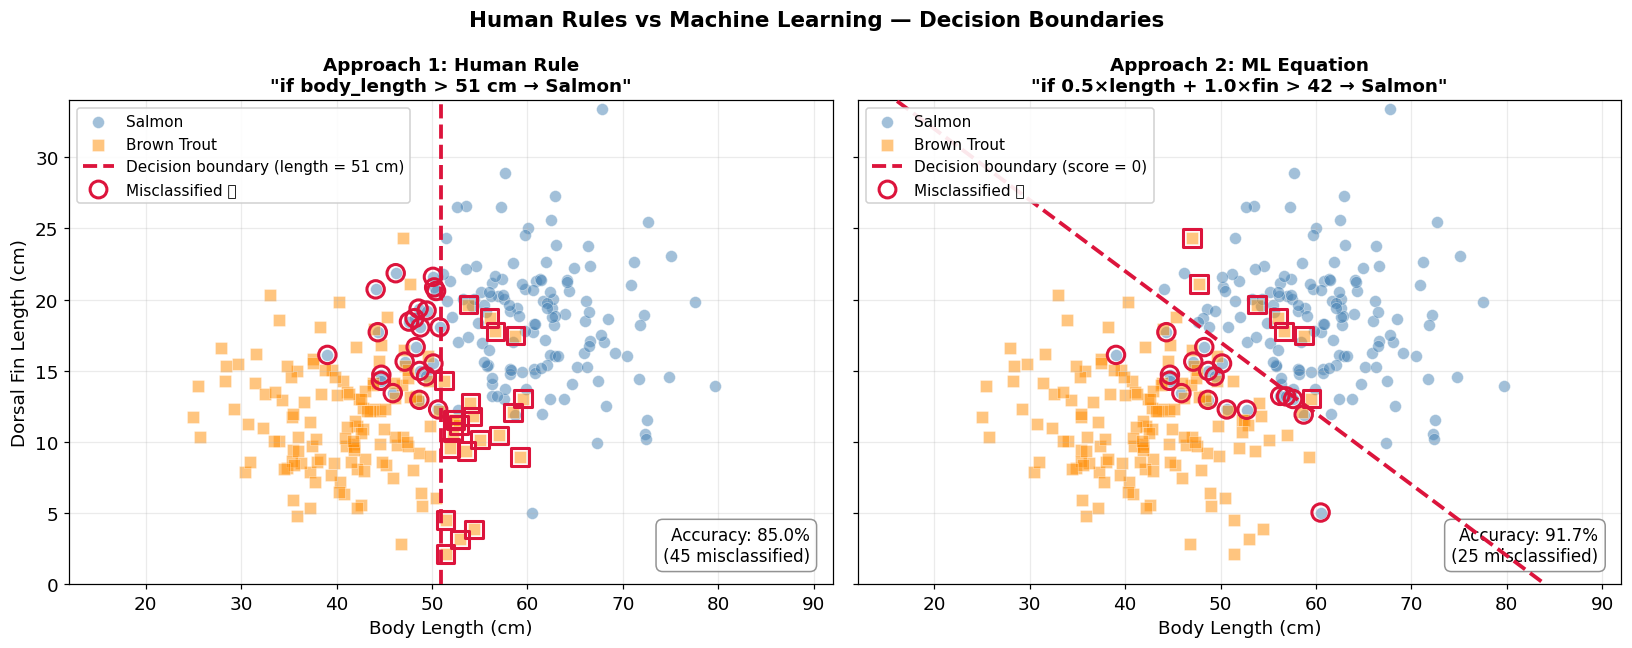

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

length_plot = np.linspace(12, 90, 400)

for ax, pred_col, title, accuracy in [
    (axes[0], 'human_pred', f'Approach 1: Human Rule\n"if body_length > {HUMAN_THRESHOLD} cm → Salmon"', human_accuracy),
    (axes[1], 'ml_pred',    f'Approach 2: ML Equation\n"if 0.5×length + 1.0×fin > 42 → Salmon"',      ml_accuracy),
]:
    # ── Plot each species ──────────────────────────────────────────────────────
    for species, colour, marker in [
        ('Salmon',      SALMON_COLOUR, 'o'),
        ('Brown Trout', TROUT_COLOUR,  's')
    ]:
        mask = df['species'] == species
        ax.scatter(
            df.loc[mask, 'body_length'], df.loc[mask, 'fin_length'],
            color=colour, marker=marker, alpha=0.50, s=60,
            edgecolors='white', linewidth=0.4, label=species
        )
        # Highlight misclassifications with a red outline
        wrong = mask & (df[pred_col] != df['species'])
        ax.scatter(
            df.loc[wrong, 'body_length'], df.loc[wrong, 'fin_length'],
            facecolors='none', edgecolors='crimson', linewidths=2.0,
            s=130, marker=marker, zorder=5
        )

    ax.set_xlabel('Body Length (cm)', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(12, 92)
    ax.set_ylim(0, 34)

    # Accuracy annotation
    n_wrong_total = (df[pred_col] != df['species']).sum()
    ax.text(
        0.97, 0.04,
        f'Accuracy: {accuracy:.1f}%\n({n_wrong_total} misclassified)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='grey')
    )

# ── Human rule boundary: vertical line at 51 cm ───────────────────────────────
axes[0].axvline(
    x=HUMAN_THRESHOLD, color='crimson', lw=2.5, linestyle='--',
    label=f'Decision boundary (length = {HUMAN_THRESHOLD} cm)', zorder=4
)
axes[0].set_ylabel('Dorsal Fin Length (cm)', fontsize=12)

# ── ML boundary: diagonal line where score = 0 ────────────────────────────────
# Rearranging:  0.5*L + 1.0*F - 42 = 0  →  F = (42 - 0.5*L) / 1.0
boundary_fin = (-BIAS - W_LENGTH * length_plot) / W_FIN
in_range = (boundary_fin >= 0) & (boundary_fin <= 34)
axes[1].plot(
    length_plot[in_range], boundary_fin[in_range],
    color='crimson', lw=2.5, linestyle='--',
    label='Decision boundary (score = 0)', zorder=4
)

# ── Shared legend additions ────────────────────────────────────────────────────
wrong_handle = mlines.Line2D(
    [], [], marker='o', color='w',
    markeredgecolor='crimson', markeredgewidth=2.0, markersize=11,
    label='Misclassified ⭕'
)
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [wrong_handle], labels + ['Misclassified ⭕'],
              fontsize=10, framealpha=0.9, loc='upper left')

plt.suptitle('Human Rules vs Machine Learning — Decision Boundaries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Comparison Summary

In [ ]:
# ── Side-by-side accuracy summary ─────────────────────────────────────────────
print("\n" + "=" * 50)
print(f"  {'Approach':<24} {'Accuracy':>10}")
print("=" * 50)
print(f"  {'Human rule (length only)':<24} {human_accuracy:>9.1f}%")
print(f"  {'ML equation (both features)':<24} {ml_accuracy:>9.1f}%")
print("=" * 50)
print(f"  Improvement from ML:         {ml_accuracy - human_accuracy:>+9.1f} pp")
print()

# ── Show some fish the human rule gets wrong but ML gets right ────────────────
rescued = df[(df['human_pred'] != df['species']) & (df['ml_pred'] == df['species'])].copy()
print(f"Fish the human rule misclassifies but ML gets RIGHT: {len(rescued)}")
print(rescued[['body_length', 'fin_length', 'species', 'human_pred', 'ml_pred']]
      .rename(columns={
          'body_length': 'length (cm)',
          'fin_length':  'fin (cm)',
          'human_pred':  'human says',
          'ml_pred':     'ML says'
      })
      .head(8)
      .to_string(index=False))

---
## 6. Key Takeaways

### What is the fundamental difference?

| | Human Rules | Machine Learning |
|---|---|---|
| **Mechanism** | Expert writes `if / else` conditions | Algorithm finds weights for a formula |
| **Features used** | One feature at a time | All features *simultaneously* |
| **Decision boundary** | Axis-aligned (vertical / horizontal) | Diagonal — or any shape with deeper models |
| **Scales to many features?** | ❌ Very hard for humans | ✅ Handled automatically |
| **Adapts to new data?** | ❌ Human must manually update rules | ✅ Retrain the algorithm |

### What does the ML equation actually *mean*?

The equation `0.5 × body_length + 1.0 × fin_length - 42 > 0` is asking:

> *"Does this fish's combination of body size and fin size look more like a Salmon than a Trout?"*

- **w₁ = 0.5** says: each extra centimetre of body length adds 0.5 to the 'Salmon score'.
- **w₂ = 1.0** says: each extra centimetre of fin length adds 1.0 — *fin length matters more per cm* because
  it has a tighter natural range, making it more discriminating.
- **b = −42** sets the zero-point — without it, *every* fish would score positive.

### Why is the diagonal boundary better?

The human rule draws a **vertical** line — it can only ask *"is the fish long enough?"*
The ML equation draws a **diagonal** line — it can ask *"is the right **combination** of
length and fin length present?"*

A short Salmon with an unusually large fin still gets classified correctly by the ML equation,
even though the human rule would call it a Trout.

### Where does real ML take this further?

In a real ML pipeline:

1. You don't set the weights by hand — a **training algorithm** (e.g. gradient descent)
   finds the best weights automatically from labelled examples.
2. You can add **many more features** (colour, weight, scale pattern, …) without rewriting any rules.
3. **Non-linear models** (e.g. Neural Networks, Random Forests) can draw curved, complex boundaries
   for problems where no straight line works.

But the core idea is always the same: *find a mathematical function that maps inputs to outputs*,
and let data — not intuition — determine its parameters.